#**1. Introduction to Altair**

## 환경 설정, 데이터 불러오기



In [ ]:
%pip install altair pandas vega_datasets matplotlib scikit-learn --quiet

In [ ]:
import altair as alt
import pandas as pd

In [ ]:
from vega_datasets import data

cars = data.cars()
pop = data.population()
gapminder = data.gapminder()

In [ ]:
data2000 = gapminder.loc[gapminder['year']==2000]

data2000.head(5)

In [ ]:
dataUS = gapminder.loc[gapminder["country"] == "United States"]
dataUS.head()

## **(1) Chart**

### bar chart

In [ ]:
# 7-8p
source = pd.DataFrame({
    'a': ['A', 'B', 'B', 'C', 'D', 'E', 'G', 'H', 'I'],
    'b': [28, 55, 43, 91, 81, 53, 19, 87, 52]
})

alt.Chart(source).mark_bar().encode(
    x='a:N',
    y='b'
)

### Scatterplot

In [ ]:
alt.Chart(cars).mark_circle(
    color='red',
    opacity=.3
).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q'
)

## **(2) Encodings**

### Position (X, Y)

In [ ]:
alt.Chart(data2000).mark_point().encode(
    alt.X('fertility:Q'),
    alt.Y('cluster:O')
)

In [ ]:
alt.Chart(data2000).mark_point().encode(
    alt.X('fertility:Q'),
    alt.Y('life_expect:Q')
)

In [ ]:
alt.Chart(data2000).mark_point().encode(
    alt.X('fertility:Q', scale=alt.Scale(zero=False)),
    alt.Y('life_expect:Q', scale=alt.Scale(zero=False))
)

#### Data Types

In [ ]:
chart_quantitative = alt.Chart(pop).mark_bar().encode(
    alt.X('year:Q'),
    alt.Y("mean(people):Q", title="total population"),
    tooltip=['year', 'people']
).properties(

    title='year:quantitative'
)

chart_ordinal = alt.Chart(pop).mark_bar().encode(
    alt.X('year:O'),
    alt.Y("mean(people):Q", title="total population"),
    tooltip=['year', 'people']
).properties(
    title='year:ordinal'
)

chart_quantitative | chart_ordinal

### Size

In [ ]:
alt.Chart(data2000).mark_point(filled=True).encode(
    alt.X('fertility:Q'),
    alt.Y('life_expect:Q'),
    alt.Size('pop:Q')
)

### Color

In [ ]:
alt.Chart(cars).mark_circle().encode(
    alt.X('Horsepower:Q'),
    alt.Y('Miles_per_Gallon:Q'),
    alt.Color('Cylinders:Q')
).properties(
    width=150,
    height=150,
    title='quantitative'
) | alt.Chart(cars).mark_circle().encode(
    alt.X('Horsepower:Q'),
    alt.Y('Miles_per_Gallon:Q'),
    alt.Color('Cylinders:O')
).properties(
    width=150,
    height=150,
    title='ordinal'
) | alt.Chart(cars).mark_circle().encode(
    alt.X('Horsepower:Q'),
    alt.Y('Miles_per_Gallon:Q'),
    alt.Color('Cylinders:N')
).properties(
    width=150,
    height=150,
    title='nominal'
)

In [ ]:
alt.Chart(data2000).mark_point(filled=True).encode(
    alt.X('fertility:Q'),
    alt.Y('life_expect:Q'),
    alt.Size('pop:Q'),
    alt.Color('cluster:N')
)

### Opacity

In [ ]:
alt.Chart(data2000).mark_point(filled=True).encode(
    alt.X('fertility:Q'),
    alt.Y('life_expect:Q'),
    alt.Size('pop:Q'),
    alt.Color('cluster:N'),
    alt.OpacityValue(0.5)
)

### Tooltip

In [ ]:
alt.Chart(data2000).mark_point(filled=True).encode(
    alt.X('fertility:Q'),
    alt.Y('life_expect:Q'),
    alt.Size('pop:Q'),
    alt.Color('cluster:N'),
    alt.OpacityValue(0.5),
    alt.Tooltip('country:N')
)

## **(3) Marks**

### Point

In [ ]:
alt.Chart(cars).mark_point().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q'
)

In [ ]:
alt.Chart(cars).mark_point().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N',
    shape='Origin:N'
)

### Bar

In [ ]:
alt.Chart(cars).mark_bar().encode(
    x='Cylinders:O',
    y='count():Q',
)

In [ ]:
alt.Chart(cars).mark_bar().encode(
    x='Cylinders:O',
    y='count():Q',
    color='Origin:N'
).facet(
    column='Origin:N'
)

In [ ]:
alt.Chart(cars).mark_bar().encode(
    x='Cylinders:O',
    y='count():Q',
    color='Origin:N'
)

### Line

In [ ]:
alt.Chart(gapminder).mark_line(point=True).encode(
    alt.X('year:O'),
    alt.Y('fertility:Q'),
    alt.Color('country:N', legend=None),
    alt.Tooltip('country:N')
).properties(width=400, height=500)

### Area

In [ ]:
alt.Chart(dataUS).mark_area().encode(
    alt.X('year:O'),
    alt.Y('fertility:Q')
)

#### Circle vs Line vs Bar vs Area

In [ ]:
alt.Chart(dataUS).mark_circle().encode(
    alt.X('year:O'),
    alt.Y('fertility:Q')
) | alt.Chart(dataUS).mark_line().encode(
    alt.X('year:O'),
    alt.Y('fertility:Q')
) | alt.Chart(dataUS).mark_bar().encode(
    alt.X('year:O'),
    alt.Y('fertility:Q')
) | alt.Chart(dataUS).mark_area().encode(
    alt.X('year:O'),
    alt.Y('fertility:Q')
)

#**2. Composition**

## 데이터 불러오기

In [ ]:
weather_url = 'https://vega.github.io/vega-datasets/data/weather.csv'

weather = pd.read_csv(weather_url)
weather.head()

## (1) Facet

In [ ]:
alt.Chart(weather).mark_bar().transform_filter(
  'datum.location == "Seattle"'
).encode(
  alt.X('temp_max:Q', bin=True, axis=alt.Axis(title='Temperature (°C)')),
  alt.Y('count():Q')
)

In [ ]:
colors = alt.Scale(
  domain=['drizzle', 'fog', 'rain', 'snow', 'sun'],
  range=['#aec7e8', '#c7c7c7', '#1f77b4', '#9467bd', '#e7ba52']
)

alt.Chart(weather).mark_bar().encode(
  alt.X('temp_max:Q', bin=True, axis=alt.Axis(title='Temperature (°C)')),
  alt.Y('count():Q'),
  alt.Color('weather:N',
            scale=colors)
).properties(
  width=150,
  height=150
).facet(
  column='weather:N'
).transform_filter(
  'datum.location == "Seattle"'
)

## (2) Repeat

In [ ]:
alt.Chart(weather).mark_point(
    filled=True, size=15, opacity=0.5).encode(
  alt.X(alt.repeat("column"), type='quantitative'),
  alt.Y(alt.repeat("row"), type='quantitative')
).properties(
  width=150,
  height=150
).repeat(
  row=['temp_max', 'precipitation', 'wind'],
  column=['wind', 'precipitation', 'temp_max']
).transform_filter(
  'datum.location == "Seattle"'
)

# Appendix

In [ ]:
alt.Chart(weather).mark_line().encode(
    alt.X('month(date):T'),
    alt.Y(alt.repeat('column'), type='quantitative', aggregate='mean'),
    alt.Color('location:N')
).properties(
    width=200,
    height=150
).repeat(
    column=['temp_max', 'precipitation', 'wind']
)

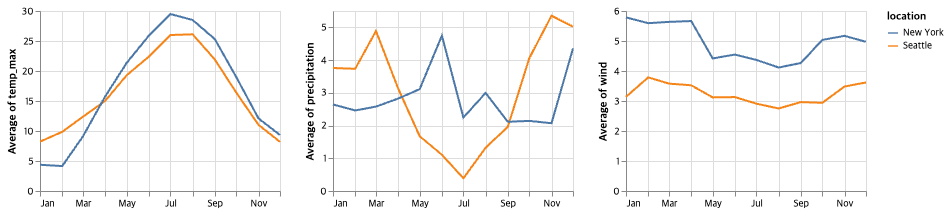

In [ ]:
penguins_url = "https://vega.github.io/vega-datasets/data/penguins.json"
penguins = pd.read_json(penguins_url)
penguins.columns = ["species", "island", "beak_length", "beak_depth", "flipper_length", "body_mass", "sex"]
penguins.head()

In [ ]:
alt.Chart(penguins).mark_point().encode(
  alt.X(alt.repeat("column"), type='quantitative', scale=alt.Scale(zero=False)),
  alt.Y(alt.repeat("row"), type='quantitative', scale=alt.Scale(zero=False)),
  alt.Color('species:N')
).properties(
  width=150,
  height=150
).repeat(
  row=['beak_length', 'beak_depth', 'flipper_length', 'body_mass'],
  column=['beak_length', 'beak_depth', 'flipper_length', 'body_mass']
)



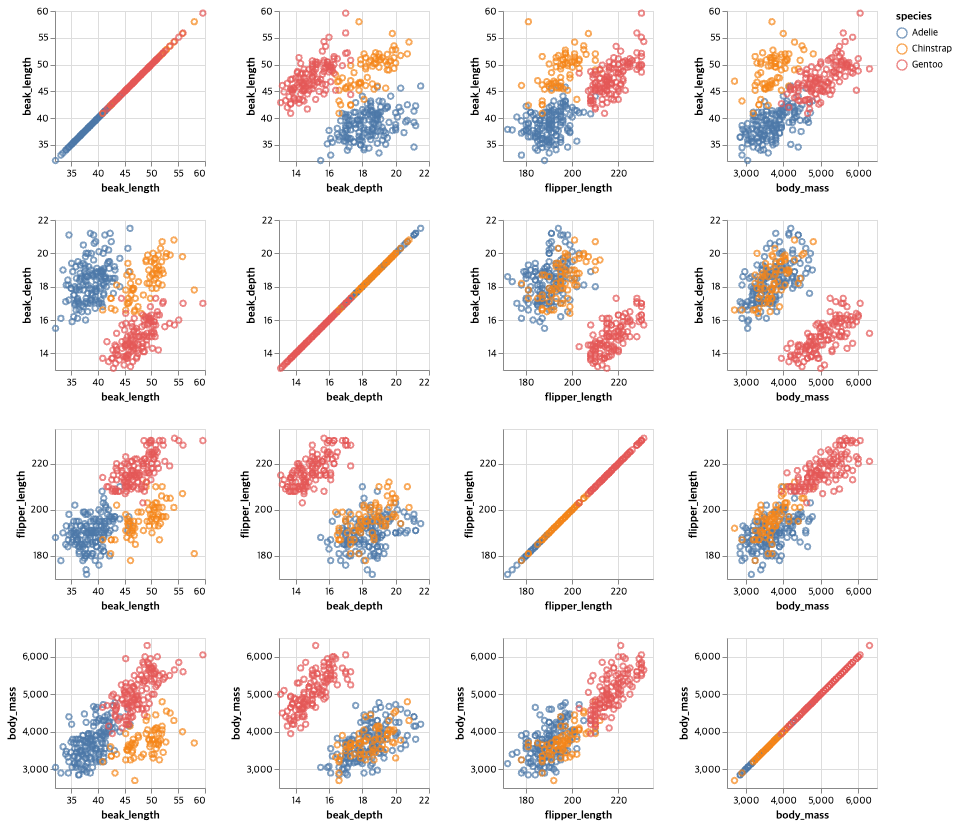

### 직접 해보기

## 차원 축소를 통한 군집 분석

고차원 데이터에서 군집의 개수를 판단하는 것은 어렵습니다. 예를 들어, `make_blobs` 함수로 생성한 데이터가 많은 차원을 가지고 있는 경우, **Random two features**처럼 임의로 두 개의 특성만 선택하여 시각화하면 실제 군집 구조를 파악하기 어렵습니다.

하지만 **차원 축소 방법(PCA, MDS, t-SNE 등)** 을 이용하면 고차원 데이터를 저차원으로 압축하여 시각화할 수 있고, 이를 통해 군집의 개수를 더 쉽게 파악할 수 있습니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Setting
n_samples = 1000
n_features = 100
centers = 4

# Generate Data
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=centers, random_state=42)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# MDS 적용
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

# t-SNE 적용
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

In [ ]:
# 차원 축소 방법들
reduction_methods = ['Random two features', 'PCA', 'MDS', 't-SNE']
reduction_X = {reduction_methods[i]:[X[:, [0, 1]], X_pca, X_mds, X_tsne][i]for i in range(len(reduction_methods))}

for k in [2,3,4,5] : 

    kmeans_assignments = {}
    # 각 method별 산점도 그리기
    plt.figure(figsize=(5*len(reduction_methods), 5))
    for i, method in enumerate(reduction_methods):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(reduction_X[method])
        kmeans_assignments[i] = kmeans.labels_
        plt.subplot(1, len(reduction_methods), i+1)
        clusters = kmeans_assignments[i]
        unique_clusters = np.unique(clusters)
        for cluster_id in unique_clusters:
            subset = reduction_X[method][clusters == cluster_id]
            plt.scatter(subset[:, 0], subset[:, 1], label=f'Cluster {cluster_id + 1}')
        plt.title(f'{method} Dimensionality Reduction Clusters')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()

    plt.tight_layout()
    plt.show()

### 결과 해석

위 시각화 결과를 통해 다음을 확인할 수 있습니다:

1. **Random two features**: 고차원 데이터에서 임의로 두 개의 특성만 선택하여 시각화하면, 실제 군집 구조를 제대로 반영하지 못하여 군집의 개수를 정확히 판단하기 어렵습니다.

2. **PCA (Principal Component Analysis)**: 주성분 분석을 통해 데이터의 분산을 최대한 보존하면서 저차원으로 변환합니다. 군집 구조를 어느 정도 보존하면서 시각화할 수 있습니다.

3. **MDS (Multidimensional Scaling)**: 데이터 포인트 간의 거리를 최대한 보존하면서 저차원 공간에 매핑합니다. 군집 간의 관계를 잘 유지하면서 시각화합니다.

4. **t-SNE (t-distributed Stochastic Neighbor Embedding)**: 지역적 구조에 중점을 두어 비슷한 데이터 포인트를 가까이 배치합니다. 일반적으로 군집 구조를 가장 명확하게 보여줍니다.

따라서 **고차원 데이터에서 군집의 개수를 판단할 때는 차원 축소 방법을 활용하는 것이 중요**합니다.
